## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
Already up to date.


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import numpy as np
import pandas as pd

from Challenge.paths import XGBOOST_DATAFRAMES

Running on local — storage at: /home/luigi/RecSys


## **Load Dataframes**

In [4]:
# Not sure if I shoul use prediction features to do correlation analysis
# Should be fine, I am only looking at feature correlation. No data leakage here.
file_path = os.path.join(XGBOOST_DATAFRAMES, "prediction_data.parquet")

df = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
df

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/prediction_data.parquet


,UserID,ItemID,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,ItemKNN_cosine_Score,ItemKNN_cosine_RankPosition,ItemKNN_cosine_Recommended,ItemKNN_jaccard_Score,ItemKNN_jaccard_RankPosition,...,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score,User_Profile_Len,Item_Global_Popularity
0,0,13,0.040529,1325,0,0.207680,545,0,0.129603,228,...,864.400024,707.630493,0.592600,-1.057776,0.079045,0.065471,0.427271,-1.248187,96,539
1,0,76,0.071208,820,0,0.415213,124,0,0.156571,183,...,211.000000,167.101608,2.677447,9.489000,0.178210,0.129551,1.451507,2.180224,96,947
2,0,86,0.316490,75,0,0.351859,194,0,0.099681,322,...,185.800003,202.099655,2.660424,8.649257,0.204315,0.144187,0.704453,-0.094114,96,4209
3,0,89,0.207234,188,0,0.504876,60,0,0.248379,82,...,163.600006,117.188286,2.385986,7.860408,0.194649,0.137918,0.859039,0.166705,96,2756
4,0,275,0.099481,571,0,0.514107,55,0,0.269671,72,...,97.800003,128.897995,3.014468,10.013057,0.283360,0.150004,0.427011,-0.799999,96,1323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3884153,27094,6724,0.020829,1984,0,0.342445,174,0,0.139733,232,...,264.250000,440.523712,3.500877,13.358681,0.279088,0.199187,1.070153,0.985070,314,277
3884154,27094,6771,0.390180,39,0,0.143310,811,0,0.075682,471,...,1518.900024,1675.966064,1.613655,1.880539,0.083989,0.102546,1.188648,3.077041,314,5189
3884155,27094,6782,0.010602,2757,0,0.266445,305,0,0.102625,325,...,387.000000,571.253113,4.138865,17.887188,0.211081,0.172878,1.268268,0.716687,314,141
3884156,27094,6941,0.141364,327,0,0.404935,119,0,0.273145,72,...,300.850006,621.634216,4.161278,17.983208,0.276996,0.167063,0.501362,0.499892,314,1880


## **Check correlation between columns**

In [5]:
# Calculate correlation matrix
correlation_matrix = df.corr()

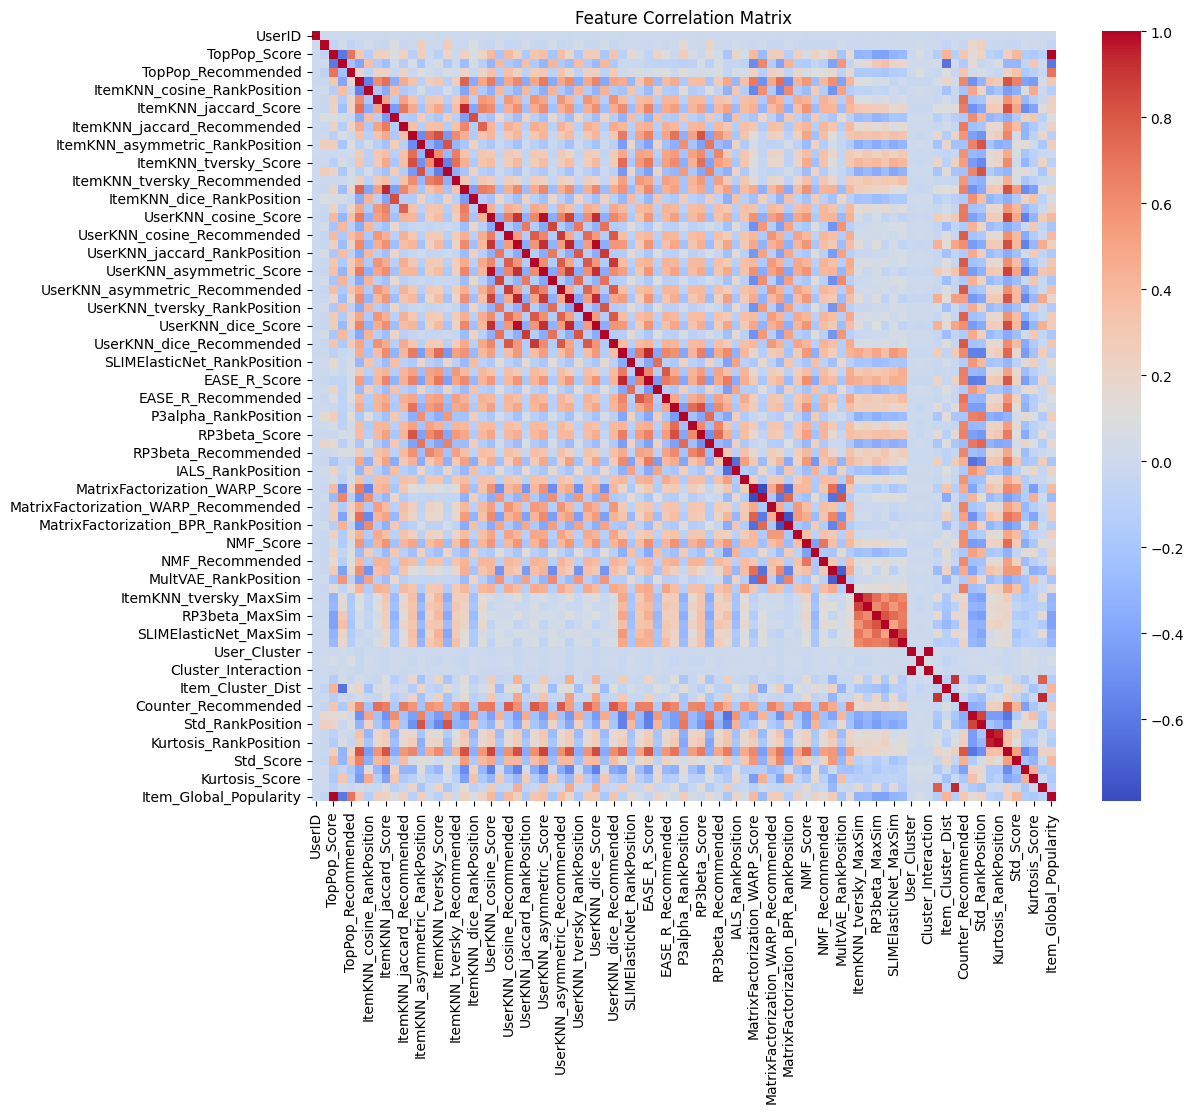

In [6]:
# Plot heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

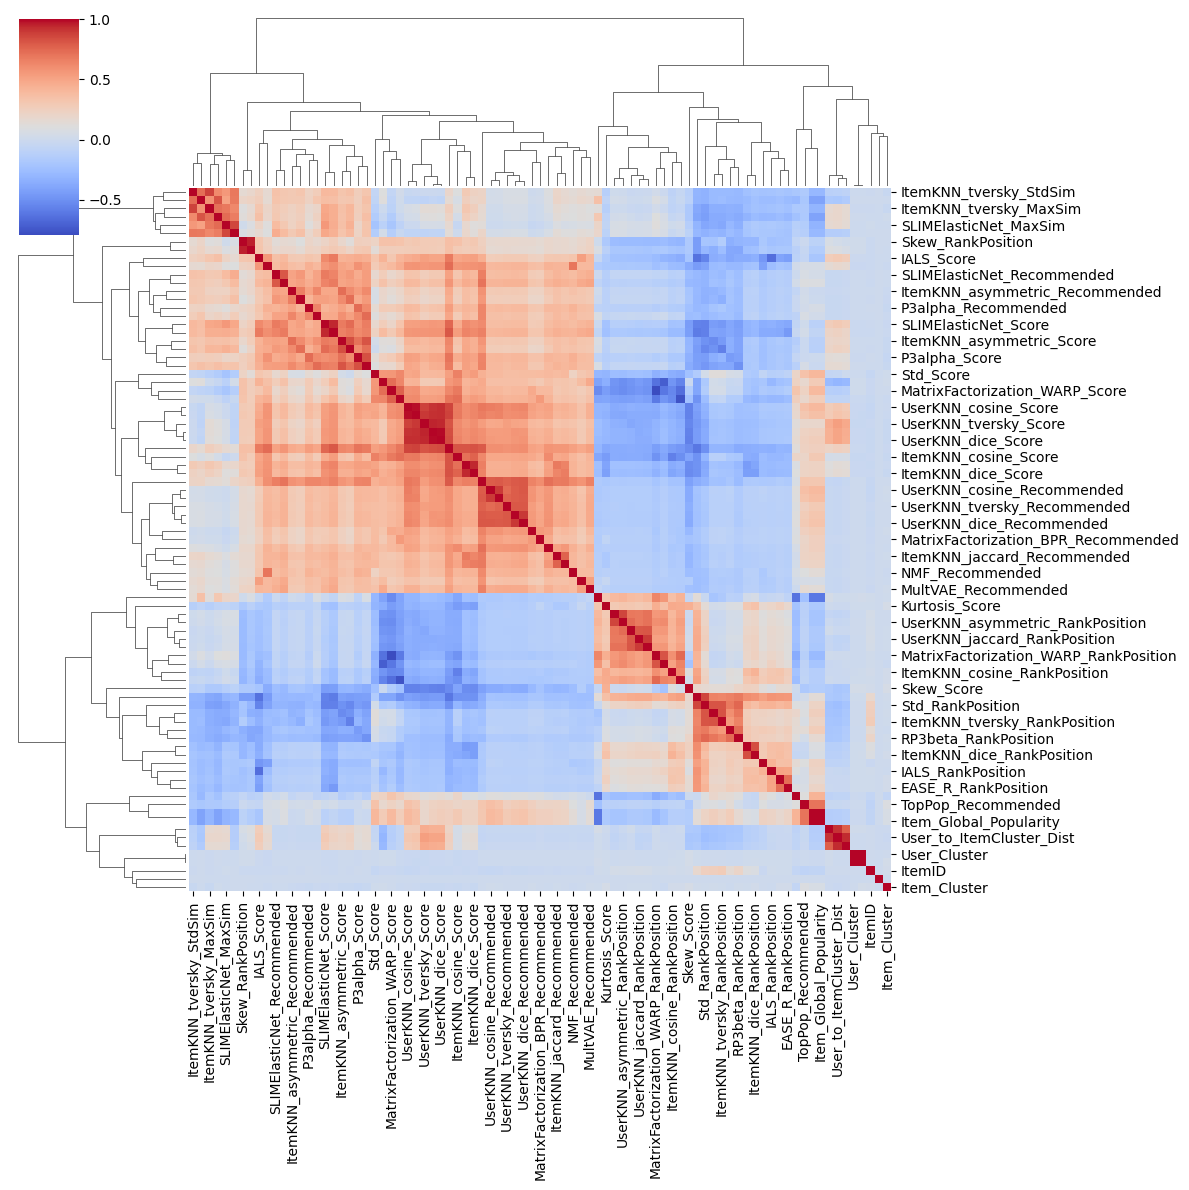

In [7]:
# No need to set figsize, clustermap handles it differently
sns.clustermap(correlation_matrix, annot=False, cmap='coolwarm', figsize=(12, 12))
plt.show()

In [8]:
import numpy as np

def get_highly_correlated_features(df, corr=None, threshold=0.95):
    # Create correlation matrix
    if corr is not None:
        corr_matrix = corr.abs()
    else:
        corr_matrix = df.corr().abs()
    
    # Select upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features with correlation greater than threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    return to_drop

# Apply to your data
cols_to_drop = get_highly_correlated_features(df, threshold=0.9, corr=correlation_matrix)
print(f"Dropping {len(cols_to_drop)} columns: {cols_to_drop}")

Dropping 12 columns: ['ItemKNN_dice_Score', 'UserKNN_jaccard_Score', 'UserKNN_asymmetric_Score', 'UserKNN_tversky_Score', 'UserKNN_dice_Score', 'UserKNN_dice_Recommended', 'EASE_R_Score', 'Cluster_Interaction', 'User_to_ItemCluster_Dist', 'Kurtosis_RankPosition', 'User_Profile_Len', 'Item_Global_Popularity']


In [9]:
df = df.drop(columns=cols_to_drop)

In [10]:
correlation_matrix = df.corr()

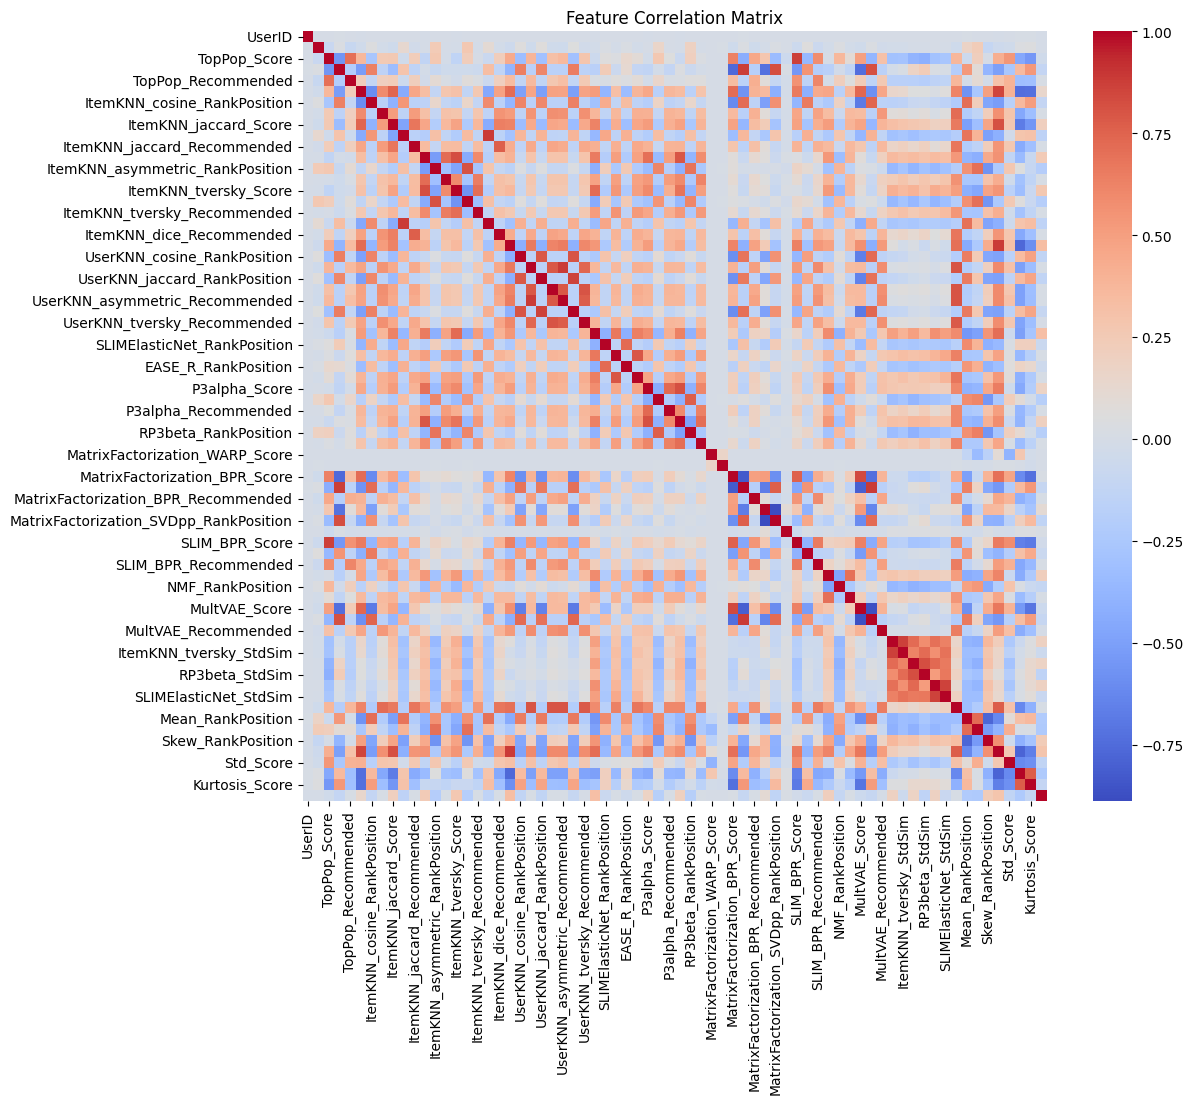

In [11]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

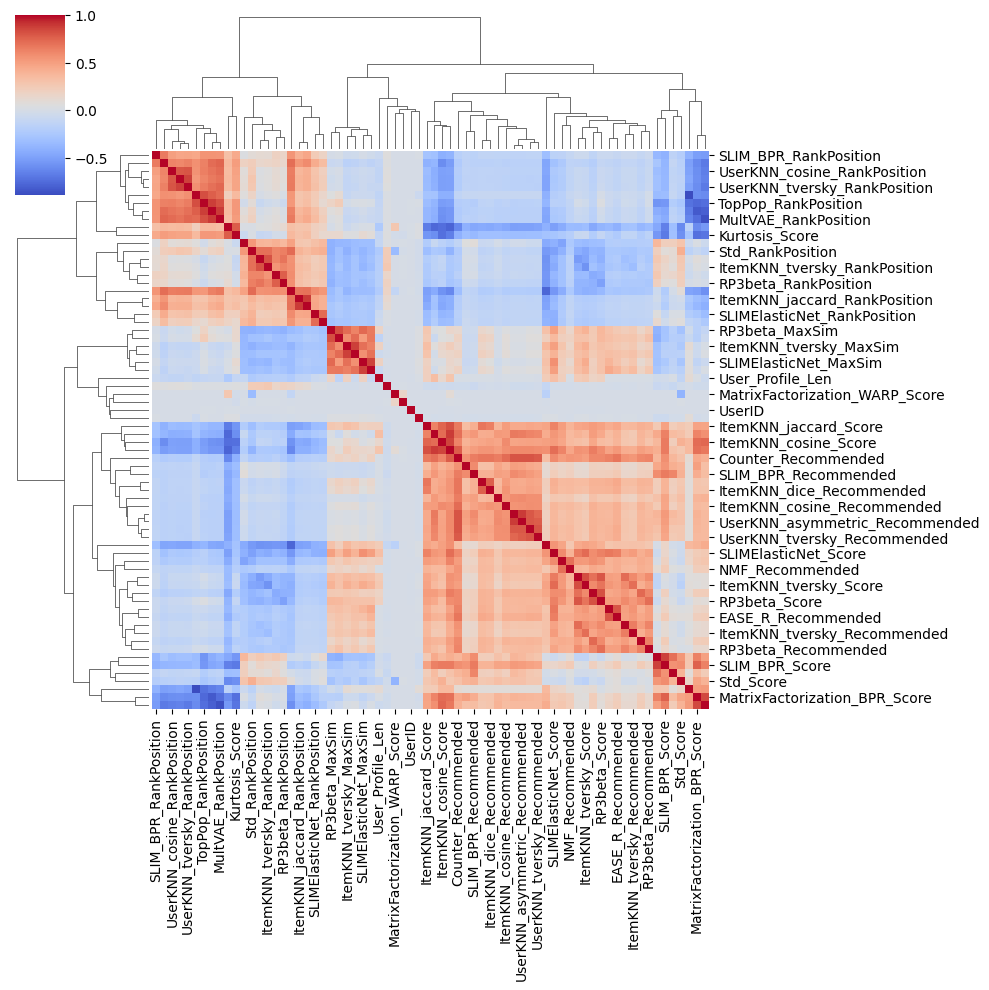

In [12]:
sns.clustermap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

In [13]:
len(df.columns)

70

In [14]:
save_path = os.path.join(XGBOOST_DATAFRAMES, "prediction_data.parquet")

df.to_parquet(
    path=save_path,
    engine='fastparquet',
    compression='zstd',
    index=False
)

print(f"Saved successfully to: {save_path}")

Saved successfully to: /home/luigi/RecSys/xg_boost_data/dataframes/prediction_data.parquet


## **Drop too correlated columns from train and val dataframes**

In [15]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "validation_data.parquet")

df = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
df

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/validation_data.parquet


,UserID,ItemID,Label,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,ItemKNN_cosine_Score,ItemKNN_cosine_RankPosition,ItemKNN_cosine_Recommended,ItemKNN_jaccard_Score,...,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score,User_Profile_Len,Item_Global_Popularity
0,0,6411,False,0.081851,717,0,0.701361,5,1,0.681310,...,407.142853,1399.072754,4.281490,18.897297,0.447156,0.278489,-1.061027,3.246427,80,874
1,0,2168,False,0.078760,750,0,0.540989,40,0,0.491260,...,358.047607,936.414124,3.650616,14.062557,0.333984,0.222666,0.733968,1.210770,80,841
2,0,6098,True,0.082225,713,0,0.708915,3,1,0.740307,...,124.571426,279.955811,2.169494,3.165847,0.503251,0.205144,0.271329,0.168902,80,878
3,0,3049,False,0.128114,412,0,0.693846,6,1,0.457670,...,321.095245,918.941772,4.353480,19.441338,0.310892,0.245103,0.985542,0.890398,80,1368
4,0,2399,False,0.442124,27,0,0.639774,15,1,0.261722,...,362.523804,1433.629395,4.515592,20.544024,0.405237,0.275703,-1.123605,4.698762,80,4721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3756433,27094,4180,False,0.367297,48,0,0.042708,2024,0,0.000000,...,3173.142822,2376.120117,0.292561,-1.572491,0.066819,0.232602,3.163013,11.877620,250,3922
3756434,27094,3236,False,0.593651,8,1,0.194622,524,0,0.114155,...,2111.714355,2253.487793,1.051186,-0.458617,0.134725,0.246047,2.432874,6.639362,250,6339
3756435,27094,4615,False,0.004402,4126,0,0.144729,767,0,0.037827,...,1697.571411,1721.538208,1.812891,2.658815,0.099026,0.205823,2.965396,11.336728,250,47
3756436,27094,6584,False,0.412343,31,0,0.112825,1005,0,0.000000,...,2309.666748,1955.347290,0.944244,-0.389569,0.105150,0.219539,3.446590,12.917460,250,4403


In [ ]:
val_cols_to_drop = get_highly_correlated_features(df, threshold=0.9)
print(f"Dropping {len(val_cols_to_drop)} columns: {val_cols_to_drop}")

if val_cols_to_drop != cols_to_drop:
    print("Mismatch in columns to drop between datasets")

Dropping 12 columns: ['ItemKNN_dice_Score', 'UserKNN_jaccard_Score', 'UserKNN_asymmetric_Score', 'UserKNN_asymmetric_RankPosition', 'UserKNN_tversky_Score', 'UserKNN_dice_Score', 'UserKNN_dice_RankPosition', 'EASE_R_Score', 'MatrixFactorization_WARP_RankPosition', 'MatrixFactorization_SVDpp_RankPosition', 'Kurtosis_RankPosition', 'Item_Global_Popularity']


AssertionError: Mismatch in columns to drop between datasets

In [17]:
val_cols_to_drop

['ItemKNN_dice_Score',
 'UserKNN_jaccard_Score',
 'UserKNN_asymmetric_Score',
 'UserKNN_asymmetric_RankPosition',
 'UserKNN_tversky_Score',
 'UserKNN_dice_Score',
 'UserKNN_dice_RankPosition',
 'EASE_R_Score',
 'MatrixFactorization_WARP_RankPosition',
 'MatrixFactorization_SVDpp_RankPosition',
 'Kurtosis_RankPosition',
 'Item_Global_Popularity']

In [18]:
cols_to_drop

['ItemKNN_dice_Score',
 'UserKNN_jaccard_Score',
 'UserKNN_asymmetric_Score',
 'UserKNN_asymmetric_RankPosition',
 'UserKNN_tversky_Score',
 'UserKNN_dice_Score',
 'UserKNN_dice_RankPosition',
 'UserKNN_dice_Recommended',
 'EASE_R_Score',
 'MatrixFactorization_WARP_RankPosition',
 'Kurtosis_RankPosition',
 'Item_Global_Popularity']

In [19]:
df = df.drop(columns=cols_to_drop)

In [20]:
save_path = os.path.join(XGBOOST_DATAFRAMES, "validation_data.parquet")

df.to_parquet(
    path=save_path,
    engine='fastparquet',
    compression='zstd',
    index=False
)

print(f"Saved successfully to: {save_path}")

Saved successfully to: /home/luigi/RecSys/xg_boost_data/dataframes/validation_data.parquet


In [22]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "training_data.parquet")

df = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
df

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/training_data.parquet


,UserID,ItemID,Label,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,ItemKNN_cosine_Score,ItemKNN_cosine_RankPosition,ItemKNN_cosine_Recommended,ItemKNN_jaccard_Score,...,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score,User_Profile_Len,Item_Global_Popularity
0,0,5609,False,0.270185,116,0,0.428426,133,0,0.415858,...,410.333344,1341.456177,4.480386,20.308155,0.292546,0.234324,0.334969,2.938539,58,2319
1,0,1940,False,0.612331,7,1,0.632690,26,0,0.494830,...,735.333313,1595.107910,2.655794,6.240859,0.406598,0.335242,-0.084116,-1.069763,60,5214
2,0,3258,True,0.078685,762,0,0.342990,255,0,0.113605,...,319.952393,688.967896,4.085459,17.637278,0.266451,0.218058,1.866132,4.445840,60,670
3,0,1504,True,0.013036,2678,0,0.349408,241,0,0.153183,...,675.000000,992.564087,1.595576,1.127617,0.228266,0.229798,1.721957,2.795686,60,111
4,0,3754,False,0.070346,845,0,0.350854,236,0,0.162925,...,455.380951,1009.099426,4.265712,18.893778,0.212713,0.210222,2.275531,7.895197,60,599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18951167,27094,5710,False,0.133869,367,0,0.234847,412,0,0.129152,...,1057.380981,1446.436890,1.583079,0.779230,0.199828,0.216875,2.181109,6.204274,203,1149
18951168,27094,922,False,0.002680,5233,0,0.016180,3255,0,0.000000,...,3547.619141,1631.819336,-1.073892,0.218229,0.032714,0.203449,3.166867,13.133365,203,23
18951169,27094,2879,False,0.002214,5769,0,0.044773,1989,0,0.000000,...,3002.523926,1880.761597,0.123180,-1.063256,0.065779,0.187186,3.228773,12.709620,203,19
18951170,27094,6584,False,0.411395,32,0,0.108802,1067,0,0.000000,...,2719.095215,2221.630859,0.494051,-1.043575,0.081124,0.232286,2.912767,10.398072,203,3531


In [23]:
df = df.drop(columns=cols_to_drop)

In [24]:
save_path = os.path.join(XGBOOST_DATAFRAMES, "training_data.parquet")

df.to_parquet(
    path=save_path,
    engine='fastparquet',
    compression='zstd',
    index=False
)

print(f"Saved successfully to: {save_path}")

Saved successfully to: /home/luigi/RecSys/xg_boost_data/dataframes/training_data.parquet
